# Multimodal Potential Analysis

In [1]:
name_of_this_notebook = 'multimodal_potential_analysis.ipynb'

SEQUENCE_LENGTH = 30
IMAGE_SIZE = (224, 224, 3)
BATCH_SIZE = 32

In [2]:
!echo "${PYTHONUNBUFFERED}"
!echo "${TF_CPP_MIN_LOG_LEVEL}"
!echo "${TF_FORCE_GPU_ALLOW_GROWTH}"
!echo "${TF_GPU_ALLOCATOR}"
!echo "${PYTHONHASHSEED}"


2
true
cuda_malloc_async



In [3]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')

Notebook log filter installed (targeted, keeps Keras steps).


In [4]:
import keras

keras.mixed_precision.set_global_policy('mixed_float16')

2025-11-24 16:29:38.209856: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-24 16:29:38.218338: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-24 16:29:38.221041: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# Ensure Determinism
import random
import numpy as np
import tensorflow as tf

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
# tf.config.experimental.enable_op_determinism()

In [6]:
# Ensure GPU works as expected
import json

print('TensorFlow Version:', tf.__version__, ';', 'Keras Version:', keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Number of GPUs detected: {len(gpus)}')
    for gpu in gpus:
        device_details = tf.config.experimental.get_device_details(gpu)
        print(f'Physical Device: {gpu.name}')
        print(f'Name: {device_details["device_name"]}')
        print(f'Compute Capability: {device_details["compute_capability"]}')
else:
    print('No GPUs were detected.')

print(json.dumps(tf.sysconfig.get_build_info(), indent=2))

TensorFlow Version: 2.17.0 ; Keras Version: 3.12.0
No GPUs were detected.
{
  "cpu_compiler": "/opt/rh/gcc-toolset-11/root/usr/bin/gcc",
  "cuda_compute_capabilities": [
    "sm_100",
    "sm_120",
    "sm_75",
    "sm_80",
    "sm_86",
    "compute_90"
  ],
  "cuda_version": "12.8",
  "cudnn_version": "9",
  "is_cuda_build": true,
  "is_rocm_build": false,
  "is_tensorrt_build": true
}


2025-11-24 16:29:39.439921: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [7]:
from keras import layers
from keras.saving import register_keras_serializable

@register_keras_serializable(package="seqaug")
class SequenceAugment(layers.Layer):
    """
    Efficient, sequence-consistent video augmentation for inputs shaped (B, T, H, W, C).
    Compatible with Keras 3.12.0 / TF 2.17.0.

    Key design choices:
    - Works in float32 [0..255] space (EfficientNetV2 handles rescaling internally).
    - Applies exactly ONE tf.map_fn over sequences (B dimension). Inside, all ops are vectorized over T frames.
    - Random parameters are sampled ONCE per sequence so all frames get the same transform (no artificial motion).
    - Positive rotation angles are COUNTER-CLOCKWISE (CCW) visually.

    Inference gating:
      Augmentations apply only when `training is True`. Evaluation/predict paths pass inputs through (casted to float32).
    """

    def __init__(
        self,
        image_size=(224, 224),         # Target (H, W) after spatial augs
        crop_scale=(0.90, 1.0),        # RandomResizedCrop: sampled scale ∈ [min,max] of original size
        rotation_max_deg=30.0,         # Uniform |angle| ∈ [0,max], random sign; positive = CCW
        fill_mode="CONSTANT",          # Rotation fill: "CONSTANT", "REFLECT", or "WRAP"
        fill_value=1.0,                # Used when fill_mode == "CONSTANT"
        flip_prob=0.5,                 # Probability to flip the whole sequence horizontally
        brightness_max_delta=20.0,     # Additive brightness jitter in 0..255 domain (sequence-consistent)
        contrast_lower=0.9, contrast_upper=1.1,  # Contrast factor range (sequence-consistent)
        gamma_range=None,              # Optional gamma jitter e.g. (0.95, 1.05); None disables
        clip_after_color=True,         # Clip to [0,255] after color ops to avoid blowouts
        noise_std=0,                   # Gaussian noise std in 0..255 domain (0 disables)
        temporal_shift_max=2,          # Roll by [-k,+k] frames
        frame_drop_prob=0.10,          # Per-frame prob to replace with previous frame
        time_mask_prob=0.10,           # Prob to mask a contiguous temporal block
        time_mask_max_frac=0.20,       # Max fraction of T for temporal block mask
        invert_prob=0.00,              # Prob to invert whole sequence (x -> 255-x).
        solarize_prob=0.05,            # Prob to solarize (> threshold).
        solarize_threshold=(120.0, 160.0),  # Threshold uniform range used when solarizing
        **kwargs
    ):
        super().__init__(**kwargs)
        self.image_size = tuple(image_size)
        self.crop_scale = tuple(crop_scale)
        self.rotation_max_deg = float(rotation_max_deg)
        self.fill_mode = str(fill_mode).upper()
        self.fill_value = float(fill_value)
        self.flip_prob = float(flip_prob)
        self.brightness_max_delta = float(brightness_max_delta)
        self.contrast_lower = float(contrast_lower)
        self.contrast_upper = float(contrast_upper)
        self.gamma_range = None if gamma_range is None else tuple(gamma_range)
        self.clip_after_color = bool(clip_after_color)
        self.noise_std = float(noise_std)
        self.temporal_shift_max = int(temporal_shift_max)
        self.frame_drop_prob = float(frame_drop_prob)
        self.time_mask_prob = float(time_mask_prob)
        self.time_mask_max_frac = float(time_mask_max_frac)
        self.invert_prob = float(invert_prob)
        self.solarize_prob = float(solarize_prob)
        self.solarize_threshold = tuple(solarize_threshold)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "image_size": self.image_size,
            "crop_scale": self.crop_scale,
            "rotation_max_deg": self.rotation_max_deg,
            "fill_mode": self.fill_mode,
            "fill_value": self.fill_value,
            "flip_prob": self.flip_prob,
            "brightness_max_delta": self.brightness_max_delta,
            "contrast_lower": self.contrast_lower,
            "contrast_upper": self.contrast_upper,
            "gamma_range": self.gamma_range,
            "clip_after_color": self.clip_after_color,
            "noise_std": self.noise_std,
            "temporal_shift_max": self.temporal_shift_max,
            "frame_drop_prob": self.frame_drop_prob,
            "time_mask_prob": self.time_mask_prob,
            "time_mask_max_frac": self.time_mask_max_frac,
            "invert_prob": self.invert_prob,
            "solarize_prob": self.solarize_prob,
            "solarize_threshold": self.solarize_threshold,
        })
        return cfg

    # ---------------------------------------------------------------------
    # Spatial / photometric (sequence-consistent across T frames)
    # ---------------------------------------------------------------------

    def _random_resized_crop_sequence(self, seq):
        """
        RandomResizedCrop for the entire sequence (same crop on all frames).
        Usage:
          - Keeps face alignment stable; avoids artificial motion from per-frame crops.
          - For tightly cropped face inputs, prefer scale in ~[0.95, 1.0].
        Input:
          seq: float32 (T, H, W, C) in [0..255]
        Output:
          cropped-resized seq: float32 (T, image_size[0], image_size[1], C)
        """
        t, h, w, c = tf.unstack(tf.shape(seq))
        s = tf.random.uniform([], self.crop_scale[0], self.crop_scale[1])
        nh = tf.maximum(1, tf.cast(s * tf.cast(h, tf.float32), tf.int32))
        nw = tf.maximum(1, tf.cast(s * tf.cast(w, tf.float32), tf.int32))

        # Top-left corner for ALL frames in the sequence
        my = tf.maximum(1, h - nh + 1)
        mx = tf.maximum(1, w - nw + 1)
        y0 = tf.random.uniform([], 0, my, dtype=tf.int32)
        x0 = tf.random.uniform([], 0, mx, dtype=tf.int32)

        # Normalized boxes for tf.image.crop_and_resize
        h_f = tf.cast(h, tf.float32); w_f = tf.cast(w, tf.float32)
        y1 = tf.cast(y0, tf.float32) / h_f
        x1 = tf.cast(x0, tf.float32) / w_f
        y2 = tf.cast(y0 + nh, tf.float32) / h_f
        x2 = tf.cast(x0 + nw, tf.float32) / w_f
        box = tf.stack([y1, x1, y2, x2], axis=0)              # (4,)
        boxes = tf.repeat(tf.expand_dims(box, 0), t, axis=0)  # (T,4)
        idx = tf.range(t, dtype=tf.int32)                     # (T,)

        # Single kernel applying identical crop to each frame
        cropped = tf.image.crop_and_resize(
            seq, boxes=boxes, box_indices=idx,
            crop_size=self.image_size, method="bilinear"
        )
        return cropped

    def _random_rotate_sequence(self, seq):
        """
        Random rotation with a single angle for the whole sequence.
        Usage:
          - Angle magnitude sampled uniformly from [0, rotation_max_deg], sign random (±).
          - Positive angles rotate CCW visually. We use inverse mapping for output->input transform.
          - Choose mild ranges (e.g., 5–8 degrees) for faces to preserve landmarks.
        Input:
          seq: float32 (T, H, W, C)
        Output:
          rotated seq: float32 (T, H, W, C)
        """
        if self.rotation_max_deg <= 0.0:
            return seq

        PI = tf.constant(np.pi, dtype=tf.float32)
        mag = tf.random.uniform([], 0.0, self.rotation_max_deg)   # [0,max]
        sgn = tf.where(tf.random.uniform([]) < 0.5, -1.0, 1.0)    # choose direction
        ang = (mag * sgn) * (PI / 180.0)

        h = tf.cast(self.image_size[0], tf.float32)
        w = tf.cast(self.image_size[1], tf.float32)
        cx = (w - 1.0) * 0.5
        cy = (h - 1.0) * 0.5
        ca = tf.math.cos(ang)
        sa = tf.math.sin(ang)

        # Output->input transform for inverse rotation (-ang)
        a0 = ca; a1 =  sa
        a3 = -sa; a4 = ca
        a2 = cx - a0 * cx - a1 * cy
        a5 = cy - a3 * cx - a4 * cy

        transform = tf.stack([a0, a1, a2, a3, a4, a5, 0.0, 0.0], axis=0)  # (8,)
        t = tf.shape(seq)[0]
        transforms = tf.repeat(tf.expand_dims(transform, 0), t, axis=0)   # (T,8)

        return tf.raw_ops.ImageProjectiveTransformV3(
            images=seq,
            transforms=transforms,
            output_shape=[self.image_size[0], self.image_size[1]],
            interpolation="BILINEAR",
            fill_mode=self.fill_mode,
            fill_value=self.fill_value,
        )

    def _maybe_hflip(self, seq):
        """
        Horizontal flip applied to all frames with probability `flip_prob`.
        Usage:
          - Keep labels correct (multiclass emotion is typically flip-safe).
          - For asymmetrical cues (e.g., text) consider disabling or lower prob.
        """
        cond = tf.less(tf.random.uniform([]), self.flip_prob)
        return tf.cond(cond, lambda: tf.image.flip_left_right(seq), lambda: seq)

    def _color_jitter(self, seq):
        """
        Sequence-consistent color jitter:
          1) Brightness: add a single delta to all frames.
          2) Contrast: scale deviations from mean by one factor.
          3) Optional gamma: tone-curve adjustment in 0..255 space.
        Usage:
          - Keep deltas modest on face data to avoid unnatural skin tones.
          - Set `clip_after_color=True` to clamp to [0,255] and avoid blown highlights.
        """
        if self.brightness_max_delta > 0:
            delta = tf.random.uniform([], -self.brightness_max_delta, self.brightness_max_delta)
            seq = tf.image.adjust_brightness(seq, delta)

        cf = tf.random.uniform([], self.contrast_lower, self.contrast_upper)
        seq = tf.image.adjust_contrast(seq, cf)

        if self.gamma_range is not None:
            g = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
            x01 = tf.clip_by_value(seq / 255.0, 0.0, 1.0)
            seq = tf.pow(x01, g) * 255.0

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    def _maybe_solarize(self, seq):
        """
        Random solarization: with probability `solarize_prob`, invert pixels above a random threshold.
        Usage:
          - Strong style augment; use sparingly (e.g., 0.02–0.08).
          - Helps encourage shape/edge reliance; may hurt if overused on small datasets.
        """
        if self.solarize_prob <= 0.0:
            return seq
        thr = tf.random.uniform([], self.solarize_threshold[0], self.solarize_threshold[1])
        def apply():
            return tf.where(seq > thr, 255.0 - seq, seq)
        cond = tf.less(tf.random.uniform([]), self.solarize_prob)
        return tf.cond(cond, apply, lambda: seq)

    def _maybe_invert(self, seq):
        """
        Full inversion: with probability `invert_prob`, apply x -> 255 - x to all frames.
        Usage:
          - Another strong style augment; try 0.02–0.05 to start.
          - Great for highlighting contours.
        """
        if self.invert_prob <= 0.0:
            return seq
        cond = tf.less(tf.random.uniform([]), self.invert_prob)
        return tf.cond(cond, lambda: 255.0 - seq, lambda: seq)

    def _gaussian_noise(self, seq):
        """
        Additive per-pixel Gaussian noise with std `noise_std` in the 0..255 domain.
        Usage:
          - Small values (e.g., 2.0–5.0) can improve robustness; keep modest for face data.
        """
        if self.noise_std > 0:
            seq = seq + tf.random.normal(tf.shape(seq), stddev=self.noise_std, dtype=tf.float32)
        
        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    # ---------------------------------------------------------------------
    # Temporal (length-preserving) — operates along T dimension
    # ---------------------------------------------------------------------

    def _temporal_ops(self, seq):
        """
        Lightweight temporal augmentation bundle:
          - Temporal shift: roll by k ∈ [-temporal_shift_max, +temporal_shift_max].
          - Frame dropout: randomly replace frames with their previous frame.
          - Temporal mask: replace a contiguous time block with the per-sequence mean frame.
        Usage:
          - Keep values mild (shift_max=1, frame_drop_prob ≤ 0.1, time_mask_prob ≤ 0.1).
          - Does not change sequence length; safe for LSTM/TCN backends.
        """
        # shift (simulate minor timing misalignment)
        if self.temporal_shift_max > 0:
            k = tf.random.uniform([], -self.temporal_shift_max, self.temporal_shift_max + 1, dtype=tf.int32)
            seq = tf.roll(seq, shift=k, axis=0)

        # frame dropout (simulate missed frames)
        if self.frame_drop_prob > 0:
            t = tf.shape(seq)[0]
            m = tf.less(tf.random.uniform([t]), self.frame_drop_prob)  # (T,)
            m = tf.reshape(m, [t, 1, 1, 1])
            prev = tf.concat([seq[0:1], seq[:-1]], axis=0)
            seq = tf.where(m, prev, seq)

        # temporal mask (block replacement)
        def apply_mask():
            t = tf.shape(seq)[0]
            maxL = tf.maximum(1, tf.cast(self.time_mask_max_frac * tf.cast(t, tf.float32), tf.int32))
            L = tf.random.uniform([], 1, maxL + 1, dtype=tf.int32)
            s = tf.random.uniform([], 0, t - L + 1, dtype=tf.int32)
            mean = tf.reduce_mean(seq, axis=0, keepdims=True)  # (1,H,W,C)
            return tf.concat([seq[:s], tf.repeat(mean, L, axis=0), seq[s+L:]], axis=0)

        cond = tf.less(tf.random.uniform([]), self.time_mask_prob)
        seq = tf.cond(cond, apply_mask, lambda: seq)
        return seq

    # ---------------------------------------------------------------------
    # Main call: one map over sequences, vectorized ops inside
    # ---------------------------------------------------------------------

    def call(self, x, training=None):
        """
        Forward pass.
        - If `training is True`: apply augmentations.
        - Else (training is False/None): return input cast to float32 (no aug).
        Inputs:
          x: uint8/float32 tensor (B, T, H, W, C)
        Returns:
          float32 tensor (B, T, H, W, C) in [~0..~255]
        """
        if training is not True:
            return tf.cast(x, tf.float32)

        x_f32 = tf.cast(x, tf.float32)

        def _per_sequence(seq):
            # Spatial/photometric (sequence-consistent)
            seq = self._random_resized_crop_sequence(seq)
            seq = self._random_rotate_sequence(seq)
            seq = self._maybe_hflip(seq)
            seq = self._color_jitter(seq)
            seq = self._maybe_solarize(seq)
            seq = self._maybe_invert(seq)
            seq = self._gaussian_noise(seq)
            # Temporal (length-preserving)
            seq = self._temporal_ops(seq)
            return seq

        # Exactly one map over sequences; inside we stay vectorized across frames
        return tf.map_fn(_per_sequence, x_f32, fn_output_signature=tf.float32)


In [8]:
custom_objects = {
    "SequenceAugment": SequenceAugment,
    # also register under the saved registered name, just to be safe
    "seqaug>SequenceAugment": SequenceAugment,
}

## Prepare Data

In [9]:
from pathlib import Path

dataset_path = Path(r'/workspace/datasets')

emotion_to_id = {
    'Anger': 0,
    'Disgust': 1,
    'Fear': 2,
    'Happiness': 3,
    'Neutral': 4,
    'Sadness': 5,
    'Surprise': 6,
}

### Prepare FEA Sequences

In [10]:
import pandas as pd

fea_dataset_path = dataset_path / 'emoji-hero-vr-db-dfea-as-csv'

fea_val_df = pd.read_csv(str(fea_dataset_path / 'validation_set.csv'))
print('fea_val_df.shape:', fea_val_df.shape)

fea_test_df = pd.read_csv(str(fea_dataset_path / 'test_set.csv'))
print('test_df.shape:', fea_test_df.shape)
print('\nColumns and Data Types:\n', fea_test_df.dtypes)

fea_val_df.shape: (11550, 66)
test_df.shape: (11340, 66)

Columns and Data Types:
 sequence_id         object
timestamp            int64
BrowLowererL       float64
BrowLowererR       float64
CheekPuffL         float64
                    ...   
UpperLidRaiserL    float64
UpperLidRaiserR    float64
UpperLipRaiserL    float64
UpperLipRaiserR    float64
Label                int64
Length: 66, dtype: object


In [11]:
def prepare_data(df: pd.DataFrame) -> dict[str, tuple[list, list, list]]:
    
    df_sorted = df.sort_values(["sequence_id", "timestamp"])
    
    sequences = dict()

    for sequence_id, group in df_sorted.groupby('sequence_id', sort=False):
        timestamps = group.iloc[:, 1].tolist()  # Select timestamp column
        features = group.iloc[:, 2:-1].values.tolist()  # Select all feature columns
        label = group.iloc[0, -1].tolist()  # Select one label per group
        sequences[sequence_id] = (timestamps, features, label)  

    return sequences


fea_sequences_val = prepare_data(fea_val_df)
fea_sequences_test = prepare_data(fea_test_df)

### Combine FEA Sequences with Image Sequences

In [12]:
image_dataset_path = dataset_path / 'emoji-hero-vr-db-di'
image_val_set_path = image_dataset_path / 'validation_set'
image_test_set_path = image_dataset_path / 'test_set'

In [13]:
def load_image_sequence_paths(image_dataset_path: Path, fea_sequences_d: dict[str, tuple[np.ndarray, int]]):
    
    print(f'\nLoading images from: {image_dataset_path}\n')
    
    fea_sequences = []
    img_sequence_paths = []
    labels = []
    perspectives = []

    for class_dir in image_dataset_path.iterdir():
        label = emotion_to_id[class_dir.name]
        for sequence_dir in class_dir.iterdir():
            sequence_id = sequence_dir.name[:-2]
            perspective = int(sequence_dir.name.split('-')[-1])
            matching_fea_sequence = fea_sequences_d.get(sequence_id)
            if matching_fea_sequence is None:
                print(f'Could not find FEA sequences for image sequence {sequence_dir.name}')
                continue
            else:
                fea_timestamps = matching_fea_sequence[0]
                fea_features = matching_fea_sequence[1]
                feas = []
                image_paths = []
                
                for i, img_path in enumerate(sorted(sequence_dir.iterdir())):
                    fea_timestamp = int(fea_timestamps[i])
                    img_timestamp = int(img_path.name.split('-')[0])
                    if fea_timestamp != img_timestamp:
                        print(f'Image and FEA timestamps do not match for image path: {img_path}')
                    else:
                        feas.append(fea_features[i])
                        image_paths.append(str(img_path))

                fea_sequences.append(feas)
                img_sequence_paths.append(image_paths)
                labels.append(label)
                perspectives.append(perspective)
        
    print(f'\nFound {len(img_sequence_paths)} image sequences with corresponding FEA sequences in {image_dataset_path}\n')
    return fea_sequences, img_sequence_paths, labels, perspectives

In [14]:
val_fea_sequences, val_img_sequences, val_labels, val_perspectives = load_image_sequence_paths(image_val_set_path, fea_sequences_val)
test_fea_sequences, test_img_sequences, test_labels, test_perspectives = load_image_sequence_paths(image_test_set_path, fea_sequences_test)


Loading images from: /workspace/datasets/emoji-hero-vr-db-di/validation_set


Found 770 image sequences with corresponding FEA sequences in /workspace/datasets/emoji-hero-vr-db-di/validation_set


Loading images from: /workspace/datasets/emoji-hero-vr-db-di/test_set


Found 756 image sequences with corresponding FEA sequences in /workspace/datasets/emoji-hero-vr-db-di/test_set



In [15]:
def parse_image(filename: str) -> tf.Tensor:
    image_string_tensor = tf.io.read_file(filename)
    image_int_tensor = tf.io.decode_jpeg(image_string_tensor, channels=IMAGE_SIZE[2])
    return image_int_tensor


def load_sequence(images_paths: tf.Tensor) -> tf.Tensor:
    images = tf.map_fn(parse_image, images_paths, fn_output_signature=tf.uint8)
    return images


def create_combined_dataset(fea_sequences:list[list[float]],
                            img_sequence_paths:list[list[str]], 
                            perspectives: list[int],
                            labels: list[int], 
                            batch_size: int) -> tf.data.Dataset:
    
    fea_sequences = tf.constant(np.array(fea_sequences), dtype=tf.float32)
    img_sequence_paths = tf.constant(np.array(img_sequence_paths), dtype=tf.string)
    perspectives = tf.constant(perspectives, dtype=tf.int32)
    labels = tf.constant(labels, dtype=tf.int32)
    
    ds = tf.data.Dataset.from_tensor_slices((fea_sequences, img_sequence_paths, perspectives, labels))

    ds = ds.map(
        lambda feas, image_paths, ps, labels: ((feas, load_sequence(image_paths), ps), labels), num_parallel_calls=tf.data.AUTOTUNE    
    )

    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

    return ds


In [16]:
val_ds = create_combined_dataset(val_fea_sequences, val_img_sequences, val_perspectives, val_labels, batch_size=BATCH_SIZE)

In [17]:
test_ds = create_combined_dataset(test_fea_sequences, test_img_sequences, test_perspectives, test_labels, batch_size=BATCH_SIZE)

## Predict Dataset

### Load Pretrained Models

In [18]:
from keras.models import load_model

models_base_path = Path.cwd().parent / 'models'
fea_model_path = models_base_path / 'fea_model.keras'
img_model_path = models_base_path / 'image_model.keras'

fea_model = load_model(str(fea_model_path))
img_model = load_model(str(img_model_path), custom_objects=custom_objects)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 20 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2025-11-24 16:29:50.793318: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 260 variables whereas the saved optimizer has 256 variables. 
  saveable.load_own_va

In [19]:
def freeze(model_or_layer):
    
    if hasattr(model_or_layer, 'trainable'):
        model_or_layer.trainable = False
    
    if hasattr(model_or_layer, 'layer'):
        freeze(model_or_layer.layer)
        
    if hasattr(model_or_layer, 'layers'):
        for layer in model_or_layer.layers:
            freeze(layer)

In [20]:
freeze(fea_model)
freeze(img_model)

### Predict FEA Sequences

In [21]:
from sklearn.metrics import classification_report

fea_val_ds = val_ds.map(lambda inputs, labels: (inputs[0], labels))

fea_val_y_pred_vectors = fea_model.predict(fea_val_ds)
fea_val_y_pred = np.argmax(fea_val_y_pred_vectors, axis=1)
fea_val_y_true = np.concatenate([y for _, y in fea_val_ds], axis=0)

val_report = classification_report(fea_val_y_true, fea_val_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(val_report)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 
              precision    recall  f1-score   support

       Anger     0.7966    0.8545    0.8246       110
     Disgust     0.7400    0.6727    0.7048       110
        Fear     0.7917    0.6909    0.7379       110
   Happiness     0.9138    0.9636    0.9381       110
     Neutral     0.9474    0.9818    0.9643       110
     Sadness     0.8421    0.8727    0.8571       110
    Surprise     0.8750    0.8909    0.8829       110

    accuracy                         0.8468       770
   macro avg     0.8438    0.8468    0.8442       770
weighted avg     0.8438    0.8468    0.8442       770



In [22]:
fea_test_ds = test_ds.map(lambda inputs, labels: (inputs[0], labels))

fea_test_y_pred_vectors = fea_model.predict(fea_test_ds)
fea_test_y_pred = np.argmax(fea_test_y_pred_vectors, axis=1)
fea_test_y_true = np.concatenate([y for _, y in fea_test_ds], axis=0)

test_report = classification_report(fea_test_y_true, fea_test_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(test_report)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

       Anger     0.9333    0.5185    0.6667       108
     Disgust     0.4921    0.5741    0.5299       108
        Fear     0.7619    0.5926    0.6667       108
   Happiness     0.7606    1.0000    0.8640       108
     Neutral     0.8475    0.9259    0.8850       108
     Sadness     0.9800    0.9074    0.9423       108
    Surprise     0.8254    0.9630    0.8889       108

    accuracy                         0.7831       756
   macro avg     0.8001    0.7831    0.7776       756
weighted avg     0.8001    0.7831    0.7776       756



### Predict Image Sequences

In [23]:
img_val_ds = val_ds.map(lambda inputs, labels: (inputs[1], labels))

img_val_y_pred_vectors = img_model.predict(img_val_ds)
img_val_y_pred = np.argmax(img_val_y_pred_vectors, axis=1)
img_val_y_true = np.concatenate([y for _, y in img_val_ds], axis=0)

val_report = classification_report(img_val_y_true, img_val_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(val_report)

25/25 ━━━━━━━━━━━━━━━━━━━━ 287s 10s/step 
              precision    recall  f1-score   support

       Anger     0.7910    0.4818    0.5989       110
     Disgust     0.6723    0.7273    0.6987       110
        Fear     0.7699    0.7909    0.7803       110
   Happiness     0.8898    0.9545    0.9211       110
     Neutral     0.8770    0.9727    0.9224       110
     Sadness     0.7154    0.8000    0.7554       110
    Surprise     0.9259    0.9091    0.9174       110

    accuracy                         0.8052       770
   macro avg     0.8059    0.8052    0.7992       770
weighted avg     0.8059    0.8052    0.7992       770



In [24]:
img_test_ds = test_ds.map(lambda inputs, labels: (inputs[1], labels))

img_test_y_pred_vectors = img_model.predict(img_test_ds)
img_test_y_pred = np.argmax(img_test_y_pred_vectors, axis=1)
img_test_y_true = np.concatenate([y for _, y in img_test_ds], axis=0)

test_report = classification_report(img_test_y_true, img_test_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(test_report)

24/24 ━━━━━━━━━━━━━━━━━━━━ 199s 8s/step
              precision    recall  f1-score   support

       Anger     0.5495    0.4630    0.5025       108
     Disgust     0.5139    0.6852    0.5873       108
        Fear     0.7320    0.6574    0.6927       108
   Happiness     0.7500    0.9167    0.8250       108
     Neutral     0.8710    0.7500    0.8060       108
     Sadness     0.8462    0.8148    0.8302       108
    Surprise     0.9158    0.8056    0.8571       108

    accuracy                         0.7275       756
   macro avg     0.7397    0.7275    0.7287       756
weighted avg     0.7397    0.7275    0.7287       756



## Analyze Results

In [25]:
fea_correct = np.sum(fea_val_y_pred == val_labels)
img_correct = np.sum(img_val_y_pred == val_labels)

print(f'VALIDATION - FEA Model - Correct Predictions: {fea_correct} out of {len(val_labels)}')
print(f'VALIDATION - Image Model - Correct Predictions: {img_correct} out of {len(val_labels)}')

VALIDATION - FEA Model - Correct Predictions: 652 out of 770
VALIDATION - Image Model - Correct Predictions: 620 out of 770


In [26]:
fea_correct = np.sum(fea_test_y_pred == test_labels)
img_correct = np.sum(img_test_y_pred == test_labels)

print(f'FEA Model - Correct Predictions: {fea_correct} out of {len(test_labels)}')
print(f'Image Model - Correct Predictions: {img_correct} out of {len(test_labels)}')

FEA Model - Correct Predictions: 592 out of 756
Image Model - Correct Predictions: 550 out of 756


In [39]:
case_counts = {
    'both_correct': np.zeros((7, 2)),
    'both_wrong': np.zeros((7, 2)),
    'image_correct_fea_wrong': np.zeros((7, 2)),
    'image_wrong_fea_correct': np.zeros((7, 2)),
}

# VAL-TEST-SWITCH
# for i in range(len(val_labels)):
#     true_label = val_labels[i]
#     img_pred = img_val_y_pred[i]
#     fea_pred = fea_val_y_pred[i]
#     perspective = int(val_perspectives[i])
    
for i in range(len(test_labels)):
    true_label = test_labels[i]
    img_pred = img_test_y_pred[i]
    fea_pred = fea_test_y_pred[i]
    perspective = int(test_perspectives[i])

    if img_pred == true_label and fea_pred == true_label:
        case_counts['both_correct'][true_label, perspective] += 1
    elif img_pred != true_label and fea_pred != true_label:
        case_counts['both_wrong'][true_label, perspective] += 1
    elif img_pred == true_label and fea_pred != true_label:
        case_counts['image_correct_fea_wrong'][true_label, perspective] += 1
    elif img_pred != true_label and fea_pred == true_label:
        case_counts['image_wrong_fea_correct'][true_label, perspective] += 1

### Save data

In [40]:
data = {
    'Emotion': [],
    'Perspective': [],
    'Case': [],
    'Count': []
}

emotions = list(emotion_to_id.keys())
cases = ['both_correct', 'image_correct_fea_wrong', 'image_wrong_fea_correct', 'both_wrong']
perspective_labels = ['Central', 'Side']

for i, emotion in enumerate(emotions):
    for j, perspective in enumerate(perspective_labels):
        for case in cases:
            count = case_counts[case][i, j]
            data['Emotion'].append(emotion)
            data['Perspective'].append(perspective)
            data['Case'].append(case)
            data['Count'].append(count)

df = pd.DataFrame(data)

csv_path = 'prediction_cases_data.csv'
df.to_csv(csv_path, index=False)
print(f'Data saved to {csv_path}')

Data saved to prediction_cases_data.csv


In [41]:
df.head(20)

,Emotion,Perspective,Case,Count
0,Anger,Central,both_correct,24.0
1,Anger,Central,image_correct_fea_wrong,4.0
2,Anger,Central,image_wrong_fea_correct,4.0
3,Anger,Central,both_wrong,22.0
4,Anger,Side,both_correct,16.0
5,Anger,Side,image_correct_fea_wrong,6.0
6,Anger,Side,image_wrong_fea_correct,12.0
7,Anger,Side,both_wrong,20.0
8,Disgust,Central,both_correct,26.0
9,Disgust,Central,image_correct_fea_wrong,12.0


In [42]:
import pandas as pd

df = pd.read_csv('prediction_cases_data.csv')
print(df.shape)
df.head()

(56, 4)


,Emotion,Perspective,Case,Count
0,Anger,Central,both_correct,24.0
1,Anger,Central,image_correct_fea_wrong,4.0
2,Anger,Central,image_wrong_fea_correct,4.0
3,Anger,Central,both_wrong,22.0
4,Anger,Side,both_correct,16.0


In [43]:
df_pivoted = df.pivot_table(index=['Emotion', 'Perspective'], columns='Case', values='Count',
                            fill_value=0).reset_index()
df_pivoted.head()

csv_path = 'pivoted_prediction_cases_data.csv'
df_pivoted.to_csv(csv_path, index=False)
print(f'Data saved to {csv_path}')

Data saved to pivoted_prediction_cases_data.csv


## Compute and Visualize Potential

In [44]:
import pandas as pd

df = pd.read_csv("pivoted_prediction_cases_data.csv")
df.head()

,Emotion,Perspective,both_correct,both_wrong,image_correct_fea_wrong,image_wrong_fea_correct
0,Anger,Central,24.0,22.0,4.0,4.0
1,Anger,Side,16.0,20.0,6.0,12.0
2,Disgust,Central,26.0,11.0,12.0,5.0
3,Disgust,Side,25.0,12.0,11.0,6.0
4,Fear,Central,23.0,12.0,10.0,9.0


In [45]:
# Total number of samples per row (Emotion + Perspective)
df['N'] = df[
    [
        'both_correct',
        'both_wrong',
        'image_correct_fea_wrong',
        'image_wrong_fea_correct',
    ]
].sum(axis=1)

# Sum over both perspectives per emotion
per_emotion = df.groupby('Emotion').sum(numeric_only=True)

# ----------------------------------------------------------------------
# Absolute counts per emotion
# ----------------------------------------------------------------------

# Number of correct predictions for image model
per_emotion['n_correct_image'] = (
    per_emotion['both_correct'] + per_emotion['image_correct_fea_wrong']
)

# Number of correct predictions for fea model
per_emotion['n_correct_fea'] = (
    per_emotion['both_correct'] + per_emotion['image_wrong_fea_correct']
)

# Number of correct predictions for oracle (image OR fea correct)
per_emotion['n_correct_oracle'] = (
    per_emotion['both_correct']
    + per_emotion['image_correct_fea_wrong']
    + per_emotion['image_wrong_fea_correct']
)

# Best single model in terms of correct predictions (absolute)
per_emotion['n_best_single_correct'] = per_emotion[
    ['n_correct_image', 'n_correct_fea']
].max(axis=1)

# Absolute gain: additional correct predictions of oracle vs. best single model
per_emotion['gain_abs'] = (
    per_emotion['n_correct_oracle'] - per_emotion['n_best_single_correct']
)

# ----------------------------------------------------------------------
# Relative metrics (accuracies and relative gain)
# ----------------------------------------------------------------------

per_emotion['acc_image'] = per_emotion['n_correct_image'] / per_emotion['N']
per_emotion['acc_fea'] = per_emotion['n_correct_fea'] / per_emotion['N']
per_emotion['acc_oracle'] = per_emotion['n_correct_oracle'] / per_emotion['N']

# Best single model accuracy
per_emotion['best_single'] = per_emotion[['acc_image', 'acc_fea']].max(axis=1)

# Relative gain in accuracy (oracle - best_single)
per_emotion['gain'] = per_emotion['acc_oracle'] - per_emotion['best_single']

# ----------------------------------------------------------------------
# Reorder columns for readability
# ----------------------------------------------------------------------

cols = [
    'N',
    'both_correct',
    'both_wrong',
    'image_correct_fea_wrong',
    'image_wrong_fea_correct',
    'n_correct_image',
    'acc_image',
    'n_correct_fea',
    'acc_fea',
    'n_correct_oracle',
    'acc_oracle',
    'n_best_single_correct',
    'best_single',
    'gain_abs',
    'gain',
]

per_emotion = per_emotion[cols]

# ----------------------------------------------------------------------
# Aggregated 'Overall' row (sums for absolute, means for relative)
# ----------------------------------------------------------------------

absolute_cols = [
    'N',
    'both_correct',
    'both_wrong',
    'image_correct_fea_wrong',
    'image_wrong_fea_correct',
    'n_correct_image',
    'n_correct_fea',
    'n_correct_oracle',
    'n_best_single_correct',
    'gain_abs',
]

relative_cols = [
    'acc_image',
    'acc_fea',
    'acc_oracle',
    'best_single',
    'gain',
]

summary = {}

# Sum over absolute columns
for col in absolute_cols:
    summary[col] = per_emotion[col].sum()

# Macro-average over emotions for relative columns
for col in relative_cols:
    summary[col] = per_emotion[col].mean()

# Append summary row
per_emotion.loc['Overall'] = summary

# ----------------------------------------------------------------------
# Convert relative metrics to percentages with two decimal places
# ----------------------------------------------------------------------

per_emotion[relative_cols] = (per_emotion[relative_cols] * 100).round(2)

# ----------------------------------------------------------------------
# Save table to CSV
# ----------------------------------------------------------------------

per_emotion.to_csv('val_fusion_results_per_emotion.csv', index=True)


In [46]:
per_emotion

,N,both_correct,both_wrong,image_correct_fea_wrong,image_wrong_fea_correct,n_correct_image,acc_image,n_correct_fea,acc_fea,n_correct_oracle,acc_oracle,n_best_single_correct,best_single,gain_abs,gain
Emotion,,,,,,,,,,,,,,,
Anger,108.0,40.0,42.0,10.0,16.0,50.0,46.30,56.0,51.85,66.0,61.11,56.0,51.85,10.0,9.26
Disgust,108.0,51.0,23.0,23.0,11.0,74.0,68.52,62.0,57.41,85.0,78.70,74.0,68.52,11.0,10.19
Fear,108.0,47.0,20.0,24.0,17.0,71.0,65.74,64.0,59.26,88.0,81.48,71.0,65.74,17.0,15.74
Happiness,108.0,99.0,0.0,0.0,9.0,99.0,91.67,108.0,100.00,108.0,100.00,108.0,100.00,0.0,0.00
Neutral,108.0,73.0,0.0,8.0,27.0,81.0,75.00,100.0,92.59,108.0,100.00,100.0,92.59,8.0,7.41
Sadness,108.0,80.0,2.0,8.0,18.0,88.0,81.48,98.0,90.74,106.0,98.15,98.0,90.74,8.0,7.41
Surprise,108.0,85.0,2.0,2.0,19.0,87.0,80.56,104.0,96.30,106.0,98.15,104.0,96.30,2.0,1.85
Overall,756.0,475.0,89.0,75.0,117.0,550.0,72.75,592.0,78.31,667.0,88.23,611.0,80.82,56.0,7.41


In [47]:
import seaborn as sns

emotions = list(emotion_to_id.keys())
cases = ['both_correct', 'both_wrong', 'image_correct_fea_wrong', 'image_wrong_fea_correct']
colors = sns.color_palette("Blues", n_colors=len(cases))
perspective_labels = ['Central', 'Side']

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# CSV-Datei laden
csv_path = 'prediction_cases_data.csv'
df = pd.read_csv(csv_path)

# DataFrame für das Diagramm vorbereiten und alphabetisch sortieren
emotions = sorted(['Neutral', 'Happiness', 'Sadness', 'Surprise', 'Fear', 'Disgust', 'Anger'])
cases = ['both_correct', 'image_wrong_fea_correct', 'image_correct_fea_wrong', 'both_wrong']

# Farbpalette definieren und Farben in der gewünschten Reihenfolge anpassen
colors = sns.color_palette('colorblind', n_colors=len(cases))
colors = [colors[2], colors[1], colors[0], colors[3]]  # Grün, helles Orange, Blau, dunkles Orange

# Summiere die Werte für beide Perspektiven
data_summed = df.groupby(['Emotion', 'Case']).sum().reset_index()

# Pivotiere das DataFrame, um es für das Plotting vorzubereiten und sortiere nach Emotionen
data_pivoted = data_summed.pivot(index='Emotion', columns='Case', values='Count').loc[emotions].fillna(0)

# Umbenennen der Labels
case_labels = {
    'both_correct': 'Both correct',
    'image_wrong_fea_correct': 'Only FEA correct',
    'image_correct_fea_wrong': 'Only Image correct',
    'both_wrong': 'Both wrong'
}

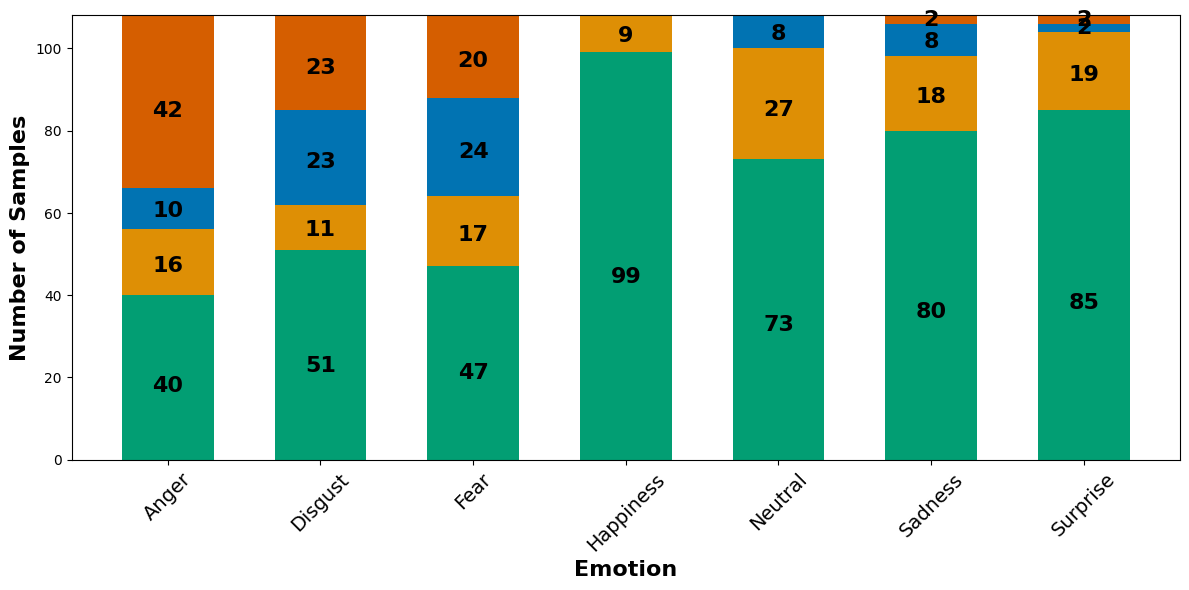

In [49]:
# Balkendiagramm erstellen
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.6  # Breite der Balken
x = np.arange(len(emotions))

# Balkendiagramm erstellen
bottom = np.zeros(len(emotions))
for i, case in enumerate(cases):
    values = data_pivoted[case].values
    bars = ax.bar(x, values, width, bottom=bottom, label=case_labels[case], color=colors[i])
    bottom += values

    # Jeden Balken mit dem Wert annotieren
    for bar in bars:
        height = bar.get_height()
        if height > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height*0.9 / 2, str(int(height)), ha='center',
                    va='center', fontsize=16, color='black', fontweight='bold')

# Beschriftungen und Titel
ax.set_xlabel('Emotion', fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=16, fontweight='bold')
# ax.set_title('Distribution of Prediction Cases by Emotion', fontsize=14, fontweight='bold')

# x-Achsen-Beschriftungen anpassen
ax.set_xticks(x)
ax.set_xticklabels(emotions, fontsize=14)

# Legende anpassen
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, labels, title='', fontsize=12, loc='upper right', bbox_to_anchor=(1.16, 1))

# x-Achsen-Beschriftungen
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('prediction_comparison.png', dpi=400)

plt.show()


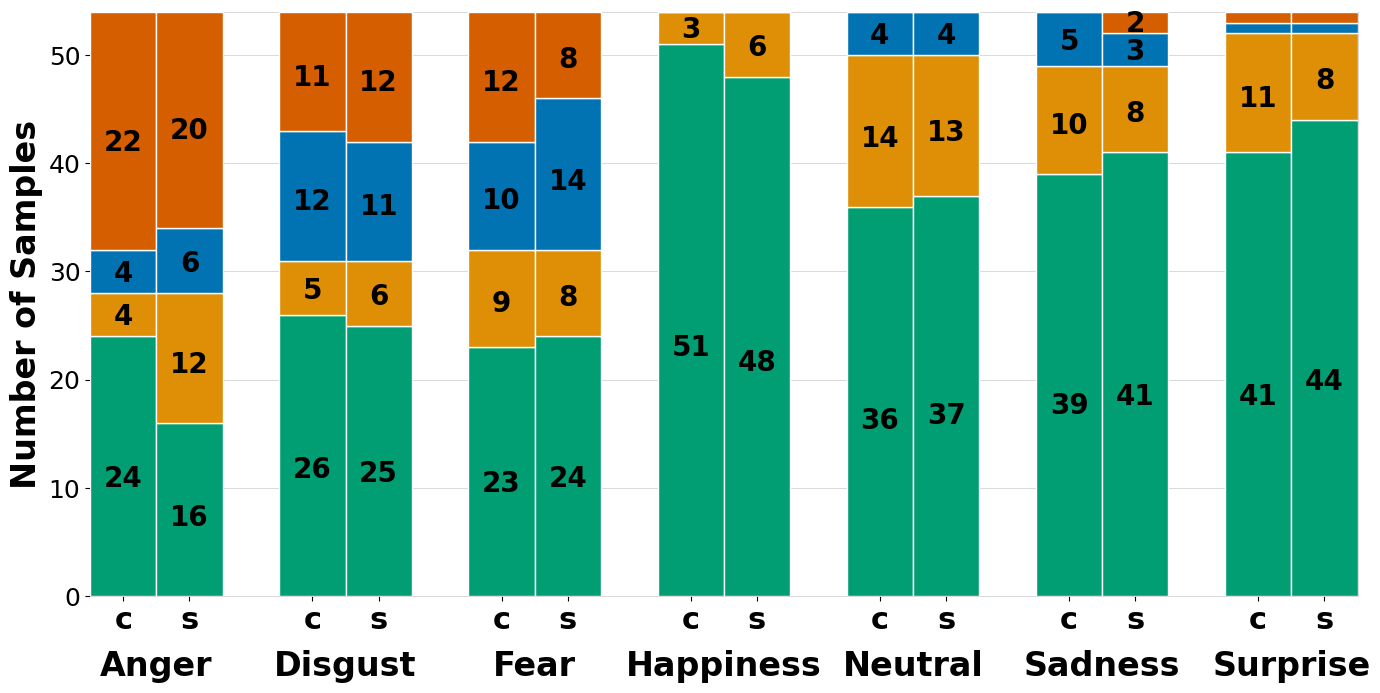

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

def plot_stacked_barchart(df):
    # DataFrame für das Diagramm vorbereiten und alphabetisch sortieren
    emotions = sorted(['Neutral', 'Happiness', 'Sadness', 'Surprise', 'Fear', 'Disgust', 'Anger'])
    cases = ['both_correct', 'image_wrong_fea_correct', 'image_correct_fea_wrong', 'both_wrong']
    perspective_labels = ['Central', 'Side']

    # Farbpalette definieren und Farben in der gewünschten Reihenfolge anpassen
    colors = sns.color_palette('colorblind', n_colors=len(cases))
    colors = [colors[2], colors[1], colors[0], colors[3]]  # Grün, helles Orange, Blau, dunkles Orange

    # Pivotiere das DataFrame, um es für das Plotting vorzubereiten und sortiere nach Emotionen
    data_pivoted = df.pivot_table(index=['Emotion', 'Perspective'], columns='Case', values='Count',
                                  fill_value=0).reset_index()
    data_pivoted = data_pivoted.set_index('Emotion').loc[emotions].reset_index()

    # Balkendiagramm erstellen
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_facecolor('white')

    # Grid hinter die Balken
    ax.grid(True, which='both', linestyle='-', linewidth=0.6,
            color='lightgray', zorder=0)
    ax.set_axisbelow(True)

    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('lightgray')
        ax.spines[spine].set_linewidth(0.6)

    width = 0.35  # Breite der Balken
    x = np.arange(len(emotions))

    # Balkendiagramm erstellen
    for j, perspective in enumerate(perspective_labels):
        bottom = np.zeros(len(emotions))
        for i, case in enumerate(cases):
            values = data_pivoted[data_pivoted['Perspective'] == perspective][case].values
            bars = ax.bar(
                x + (j - 0.5) * width,
                values,
                width,
                bottom=bottom,
                label=case_labels[case] if j == 0 else None,
                color=colors[i],
                edgecolor='white',    # dünne weiße Ränder
                linewidth=1.0,        # Dicke der Ränder
                zorder=3              # Balken über dem Grid
            )
            bottom += values

            # Jeden Balken mit dem Wert annotieren
            for bar in bars:
                height = bar.get_height()
                if height > 1:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + height * 0.9 / 2,
                        str(int(height)),
                        ha='center', va='center',
                        fontsize=20, color='black', fontweight='bold'
                    )

    # Beschriftungen und Titel
    ax.set_ylabel('Number of Samples', fontsize=24, fontweight='bold')
    ax.tick_params(axis='y', labelsize=18)

    # x-Achsen-Beschriftungen anpassen
    xticks = []
    xticklabels = []
    for i, emotion in enumerate(emotions):
        xticks.append(x[i] - width / 2)
        xticks.append(x[i] + width / 2)
        xticklabels.append('c')
        xticklabels.append('s')

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=22, fontweight='bold')

    # Emotionen über den c/s-Labels
    for i, emotion in enumerate(emotions):
        ax.text(x[i], -5, emotion, ha='center', va='top',
                fontsize=24, fontweight='bold')

    ax.set_xlim(x[0] - width, x[-1] + width)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('prediction_comparison_central_and_side.png', dpi=400)
    plt.show()


# Beispielaufruf der Funktion
plot_stacked_barchart(df=pd.read_csv('prediction_cases_data.csv'))


### Validation

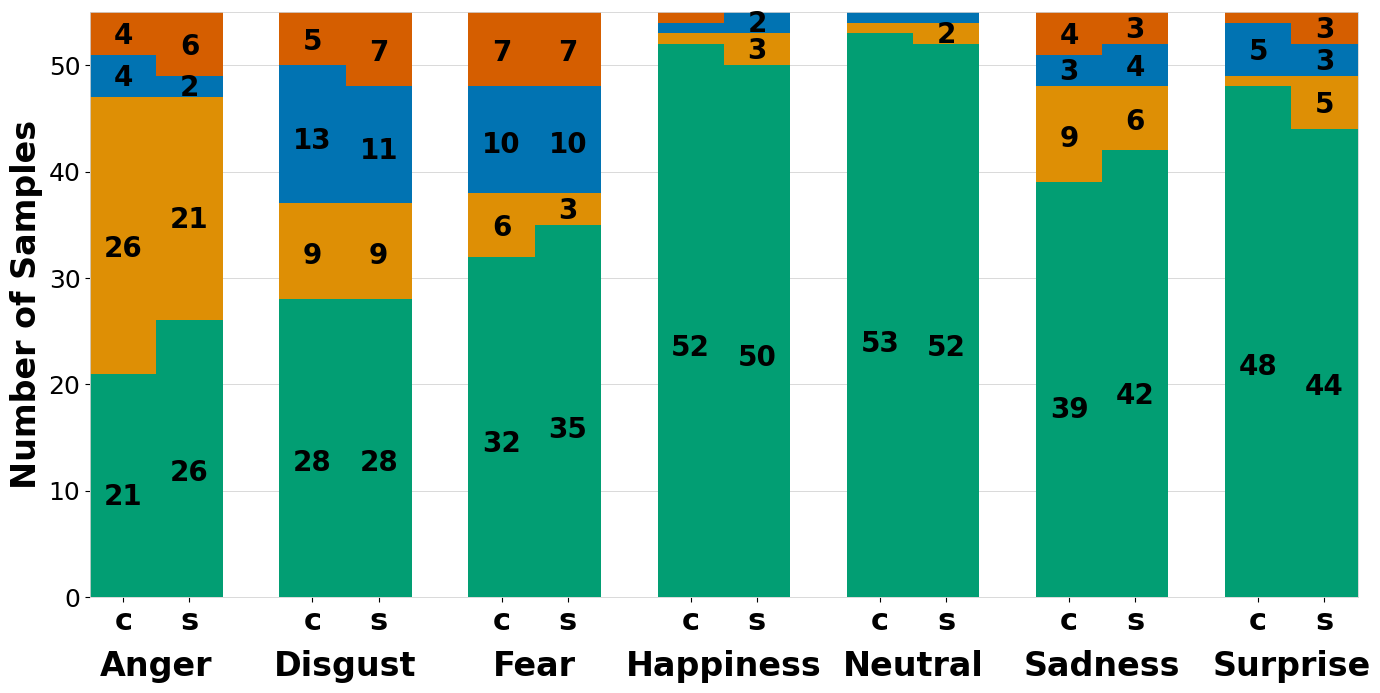

In [54]:
plot_stacked_barchart(df=pd.read_csv('val_prediction_cases_data.csv'))